# E-commerce


## Этап 1. Симуляция данных e-commerce

In [111]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect('ecommerce.db')
cursor = conn.cursor()

cursor.executescript('''
DROP TABLE IF EXISTS orders;
CREATE TABLE orders (order_id INT, seller_id TEXT, gmv REAL, status TEXT);
''')

np.random.seed(42)
data = []
for i in range(1, 15):
    seller = f"Seller_{i}"
    for _ in range(np.random.randint(50, 200)):
        status = np.random.choice(['Delivered', 'Refunded'], p=[0.92, 0.08])
        gmv = round(np.random.uniform(20, 150), 2)
        data.append((len(data)+1, seller, gmv, status))

for i in range(15, 20):
    seller = f"Seller_{i} (Toxic)"
    for _ in range(np.random.randint(30, 100)):
        status = np.random.choice(['Delivered', 'Refunded'], p=[0.65, 0.35])
        gmv = round(np.random.uniform(50, 300), 2)
        data.append((len(data)+1, seller, gmv, status))

cursor.executemany("INSERT INTO orders VALUES (?, ?, ?, ?)", data)
conn.commit()
print("База создана! Таблица 'orders' готова к твоим SQL-запросам.")

База создана! Таблица 'orders' готова к твоим SQL-запросам.


## Этап 2. Добавляем архитектуру реального бизнеса

In [112]:
import sqlite3
import pandas as pd
import numpy as np

# Подключаемся к базе
conn = sqlite3.connect('ecommerce.db')
cursor = conn.cursor()

# 1. Пересоздаем таблицу orders с чистыми ID
cursor.execute("DROP TABLE IF EXISTS orders;")
cursor.execute("""
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    seller_id TEXT,
    gmv REAL,
    status TEXT
);
""")

# 2. Создаем новую таблицу logistics
cursor.execute("DROP TABLE IF EXISTS logistics;")
cursor.execute("""
CREATE TABLE logistics (
    order_id INTEGER PRIMARY KEY,
    delivery_company TEXT,
    warehouse_region TEXT
);
""")

# Генерируем данные
np.random.seed(42)
num_orders = 1000
sellers = [f"Seller_{i}" for i in range(1, 21)] + [f"Seller_{i} (toxic)" for i in range(21, 26)]
companies = ['СДЭК', 'Почта России', 'Ozon Rocket', 'Boxberry']
regions = ['Москва', 'Санкт-Петербург', 'Краснодар', 'Новосибирск']

orders_data = []
logistics_data = []

for order_id in range(10001, 10001 + num_orders):
    seller = np.random.choice(sellers)
    gmv = round(float(np.random.exponential(scale=3000) + 500), 2)

    # У токсичных продавцов шанс возврата выше
    if "(toxic)" in seller:
        status = np.random.choice(['Delivered', 'Refunded'], p=[0.6, 0.4])
    else:
        status = np.random.choice(['Delivered', 'Refunded'], p=[0.92, 0.08])

    orders_data.append((order_id, seller, gmv, status))

    # Какая-то компания и регион везли этот заказ
    company = np.random.choice(companies)
    region = np.random.choice(regions)
    logistics_data.append((order_id, company, region))

# Заливаем данные в базу
cursor.executemany("INSERT INTO orders VALUES (?, ?, ?, ?);", orders_data)
cursor.executemany("INSERT INTO logistics VALUES (?, ?, ?);", logistics_data)
conn.commit()

print("База данных успешно усложнена! Созданы таблицы 'orders' и 'logistics'.")

База данных успешно усложнена! Созданы таблицы 'orders' и 'logistics'.


In [113]:
# Настраиваем связь
sql_query = """
SELECT *
FROM orders
"""
df_result = pd.read_sql_query(sql_query, conn)
df_result

,order_id,seller_id,gmv,status
0,10001,Seller_7,5276.90,Delivered
1,10002,Seller_21 (toxic),1008.87,Delivered
2,10003,Seller_24 (toxic),1718.08,Delivered
3,10004,Seller_21 (toxic),11010.67,Refunded
4,10005,Seller_21 (toxic),3382.93,Refunded
...,...,...,...,...
995,10996,Seller_14,3324.38,Refunded
996,10997,Seller_13,2393.72,Delivered
997,10998,Seller_16,3365.51,Delivered
998,10999,Seller_7,8708.06,Delivered


In [114]:

sql_query = """
SELECT
  seller_id AS "Продавец",
  SUM(gmv) AS "GMV",
  COUNT(order_id) AS "Общее кол-во заказов",
  SUM(CASE
    WHEN status = 'Refunded'THEN 1.0
    ELSE 0
    END) AS "Всего возвратов",
    SUM(CASE
    WHEN status = 'Refunded'THEN 1.0
    ELSE 0
    END)/COUNT(order_id) AS "Доля возвратов"
FROM orders
GROUP BY seller_id
HAVING SUM(CASE
    WHEN status = 'Refunded'THEN 1.0
    ELSE 0
    END)/COUNT(order_id)>0.3;
"""

df_result = pd.read_sql_query(sql_query, conn)
df_result.tail()


,Продавец,GMV,Общее кол-во заказов,Всего возвратов,Доля возвратов
0,Seller_21 (toxic),125282.06,37,13.0,0.351351
1,Seller_22 (toxic),159660.94,43,15.0,0.348837
2,Seller_23 (toxic),154654.29,45,17.0,0.377778
3,Seller_24 (toxic),171380.99,48,20.0,0.416667
4,Seller_25 (toxic),169072.68,45,22.0,0.488889


In [115]:
df_result['Убытки от логистики']=df_result['Общее кол-во заказов']*150 #считаем, что возврат одного товара обходится в 150 р.
df_result

,Продавец,GMV,Общее кол-во заказов,Всего возвратов,Доля возвратов,Убытки от логистики
0,Seller_21 (toxic),125282.06,37,13.0,0.351351,5550
1,Seller_22 (toxic),159660.94,43,15.0,0.348837,6450
2,Seller_23 (toxic),154654.29,45,17.0,0.377778,6750
3,Seller_24 (toxic),171380.99,48,20.0,0.416667,7200
4,Seller_25 (toxic),169072.68,45,22.0,0.488889,6750


In [116]:
df_sorted= df_result.sort_values(by='Убытки от логистики', ascending = False)
df_sorted

,Продавец,GMV,Общее кол-во заказов,Всего возвратов,Доля возвратов,Убытки от логистики
3,Seller_24 (toxic),171380.99,48,20.0,0.416667,7200
4,Seller_25 (toxic),169072.68,45,22.0,0.488889,6750
2,Seller_23 (toxic),154654.29,45,17.0,0.377778,6750
1,Seller_22 (toxic),159660.94,43,15.0,0.348837,6450
0,Seller_21 (toxic),125282.06,37,13.0,0.351351,5550


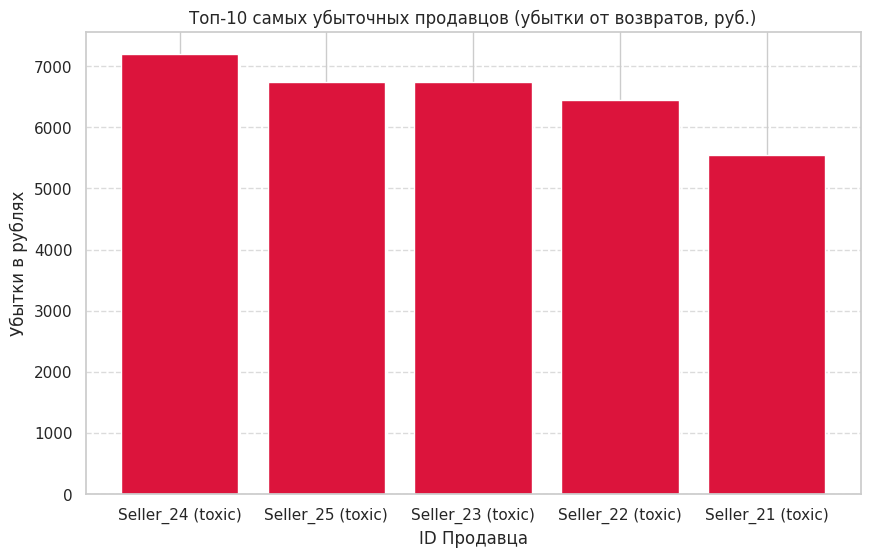

In [117]:
import matplotlib.pyplot as plt

# Берем первые 10 самых убыточных продавцов для графика
top_toxic = df_sorted.head(10)

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6)) # Задаем размер картинки
plt.bar(top_toxic['Продавец'].astype(str), top_toxic['Убытки от логистики'], color='crimson')

# Добавляем подписи, чтобы всё было красиво
plt.title('Топ-10 самых убыточных продавцов (убытки от возвратов, руб.)')
plt.xlabel('ID Продавца')
plt.ylabel('Убытки в рублях')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Добавляем легкую сетку на задний план

# Показываем график
plt.show()

In [118]:
df_result

,Продавец,GMV,Общее кол-во заказов,Всего возвратов,Доля возвратов,Убытки от логистики
0,Seller_21 (toxic),125282.06,37,13.0,0.351351,5550
1,Seller_22 (toxic),159660.94,43,15.0,0.348837,6450
2,Seller_23 (toxic),154654.29,45,17.0,0.377778,6750
3,Seller_24 (toxic),171380.99,48,20.0,0.416667,7200
4,Seller_25 (toxic),169072.68,45,22.0,0.488889,6750


In [119]:
sql_query="""
--соединяем таблицы order и delivery
SELECT
  l.delivery_company,
  --считаем общее количество заказов
  COUNT(o.order_id) AS "Общее кол-во заказов",
  -- считаем долю возвратов
  SUM(CASE
    WHEN o.status = 'Refunded' THEN 1.0
    ELSE 0 END) / COUNT(o.order_id) AS "Доля возвратов"
FROM orders o
INNER JOIN logistics l ON l.order_id = o.order_id
--сортировуем по убыванию доли возвратов
GROUP BY l.delivery_company
ORDER BY SUM(CASE
  WHEN o.status = 'Refunded' THEN 1.0
  ELSE 0 END) / COUNT(o.order_id) DESC
"""
df_result = pd.read_sql_query(sql_query, conn)
df_result.head()

,delivery_company,Общее кол-во заказов,Доля возвратов
0,Ozon Rocket,264,0.178030
1,Почта России,246,0.150407
2,Boxberry,247,0.129555
3,СДЭК,243,0.106996


In [120]:
sql_query="""
SELECT
  o.seller_id,
  l.delivery_company,
  COUNT(o.order_id) AS "Общее кол-во заказов",
  SUM(CASE WHEN o.status="Refunded" THEN 1.0 ELSE 0 END) / COUNT(o.order_id) AS "Доля возвратов"
  FROM orders o
  INNER JOIN logistics l ON o.order_id = l.order_id
  GROUP BY o.seller_id, l.delivery_company
  HAVING COUNT(o.order_id)>10
  ORDER BY "Доля возвратов" DESC;
"""
df_result = pd.read_sql_query(sql_query, conn)
df_result.head(10)

# Если в памяти остался объединенный df_join (суть в том, что можно по триста раз не переписывать функцию SQL INNER JOIN, так как у нас есть пандас мы можем вложить в переменную объединенную таблицу и обращаться к этой переменной df в будущем):
# df_anomaly = df_join.groupby(['seller_id', 'delivery_company']).agg(
#     total_orders=('order_id', 'count'),
#     refund_rate=('status', lambda x: (x == 'Refunded').sum() / len(x))
# ).reset_index()

# df_anomaly = df_anomaly.sort_values(by='refund_rate', ascending=False)
# df_anomaly.head()

# или мы можем создать функцию слепок в SQL и обращаться к ней если не хотим пользоваться пандасом
# SQL_query="""
# --Запускается один раз:
# CREATE VIEW IF NOT EXISTS v_joined_orders AS
# SELECT o.order_id, o.seller_id, o.status, l.delivery_company
# FROM orders o
# INNER JOIN logistics l ON l.order_id = o.order_id
# """
# после этого ты можешь далее не писать INNER JOIN снова, а просто написать SELECT ... FROM v_joined_orders GROUP BY
# пользуйся этим осмысленно - это очень удобно

,seller_id,delivery_company,Общее кол-во заказов,Доля возвратов
0,Seller_22 (toxic),Boxberry,11,0.545455
1,Seller_23 (toxic),Почта России,13,0.538462
2,Seller_24 (toxic),Ozon Rocket,13,0.461538
3,Seller_25 (toxic),Boxberry,13,0.461538
4,Seller_25 (toxic),Ozon Rocket,11,0.454545
5,Seller_25 (toxic),СДЭК,12,0.416667
6,Seller_21 (toxic),Ozon Rocket,15,0.400000
7,Seller_24 (toxic),Boxberry,19,0.368421
8,Seller_24 (toxic),СДЭК,11,0.363636
9,Seller_23 (toxic),Ozon Rocket,16,0.312500


Проблема не в логистике. На платформе есть пул продавцов с пометкой Toxic, у которых доля возвратов стабильно превышает 60\% независимо от того, кто везет товар. Рекомендую заблокировать этих селлеров или отправить их карточки на жесткую модерацию. Это сэкономит компании миллионы на покатушках бракованного товара туда-обратно».

/tmp/ipykernel_755/1726190444.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


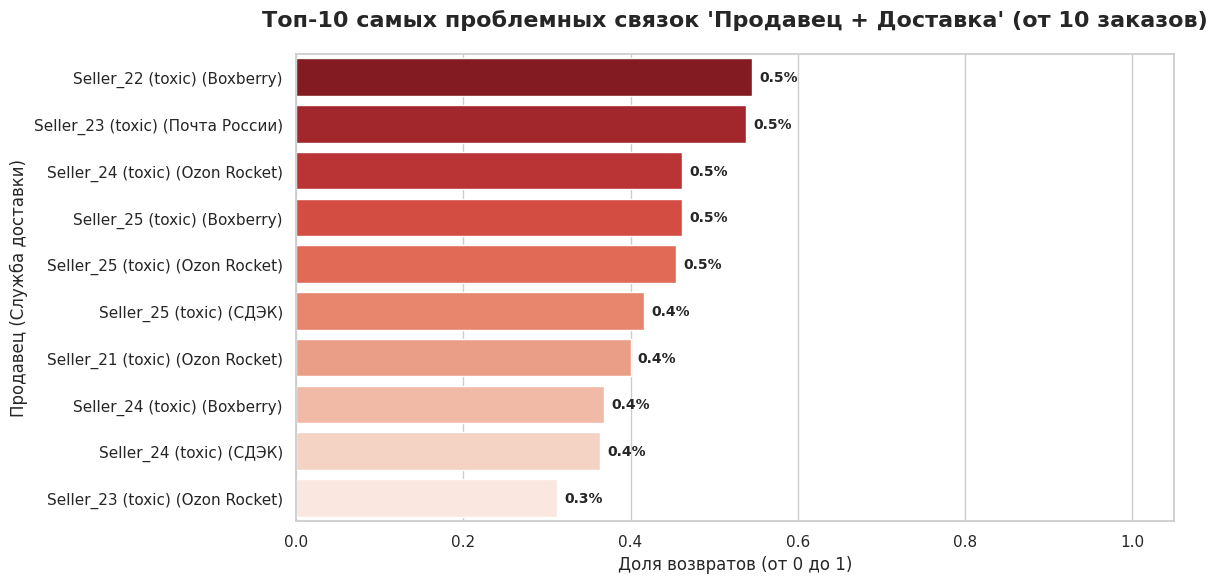

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Настройка подложки
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. Пересоздаем метку (на всякий случай)
df_result['Seller_Delivery'] = df_result['seller_id'].astype(str) + " (" + df_result['delivery_company'] + ")"

# 3. График
ax = sns.barplot(
    x="Доля возвратов",
    y="Seller_Delivery",
    data=df_result.head(10),
    palette="Reds_r"
)

# 4. Подписи данных (Data Labels) прямо на столбцы
for container in ax.containers:
    # Задаем формат процентов (например, 66.0%)
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

# 5. Фиксируем шкалу X от 0 до 1 (чтобы показать долю от целого)
plt.xlim(0, 1.05)

# 6.Заголовки
plt.title("Топ-10 самых проблемных связок 'Продавец + Доставка' (от 10 заказов)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Доля возвратов (от 0 до 1)", fontsize=12)
plt.ylabel("Продавец (Служба доставки)", fontsize=12)

plt.tight_layout()
plt.show()

In [122]:
df_result.to_csv('SQL Project 2.csv', index=False)